In [1]:
!python3 --version


Python 3.11.15


In [1]:
import math
from pathlib import Path
import glob
import os
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
from IPython.display import display

In [2]:
# Configure MediaPipe shortcuts
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
plt.rcParams['figure.figsize'] = (6,6)

In [4]:
# Load images from a local folder (data/images/input).
try:
    REPO_ROOT = Path(__file__).resolve().parents[2]
except NameError:
    REPO_ROOT = Path.cwd()
    for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        if (candidate / "data" / "images" / "input").exists():
            REPO_ROOT = candidate
            break

IMAGE_DIR = REPO_ROOT / "data" / "images" / "input"
if not IMAGE_DIR.exists():
    IMAGE_DIR = REPO_ROOT

OUTPUT_DIR = REPO_ROOT / "src" / "notebook" / "data" / "images" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DESIRED_HEIGHT = 480
DESIRED_WIDTH = 480

def save_output_image(image, name, prefix="pose"):
    save_path = OUTPUT_DIR / f"{prefix}_{name}"
    ok = cv2.imwrite(str(save_path), image)
    if ok:
        print(f"Saved output to: {save_path}")
    else:
        print(f"Failed to save output to: {save_path}")
    return save_path

def resize_and_show(image):
    if image is None or image.size == 0:
        print("Empty image.")
        return

    h, w = image.shape[:2]
    if h == 0 or w == 0:
        print("Invalid image shape.")
        return

    scale = min(DESIRED_WIDTH / w, DESIRED_HEIGHT / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    img = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Convert BGR to RGB for matplotlib display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

classroom1.jpg


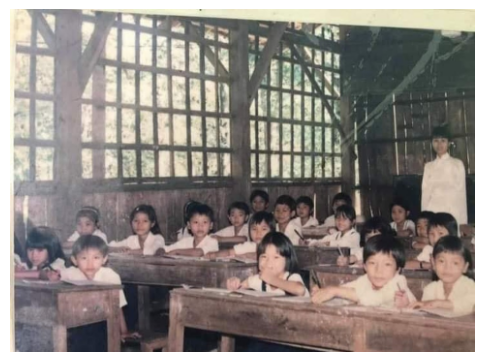

classroom2.jpg


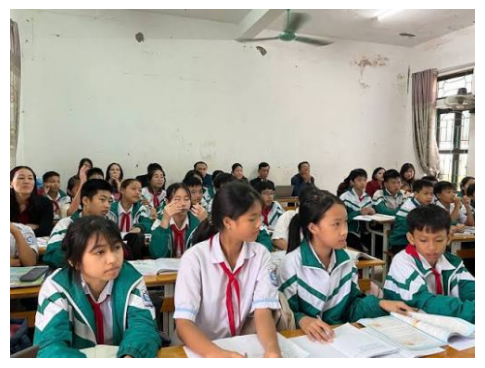

classroom3.jpg


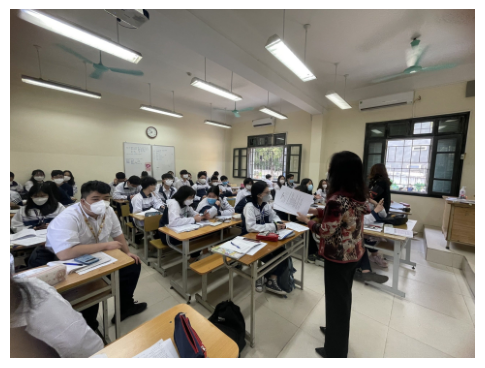

classroom4.jpg


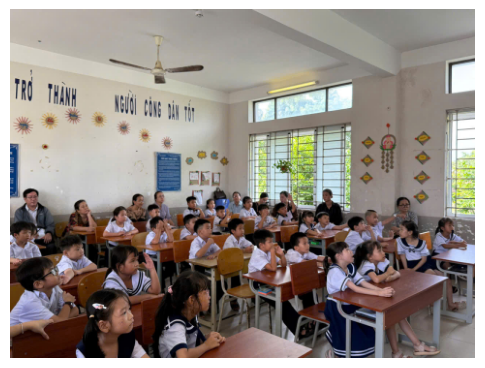

classroom5.jpg


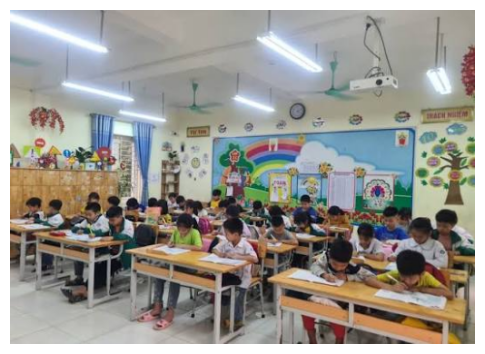

images_man_standing.jpeg


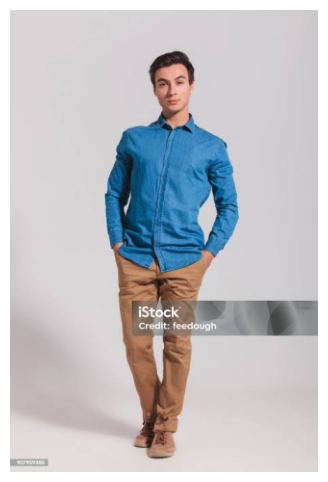

Help on class Pose in module mediapipe.python.solutions.pose:

class Pose(mediapipe.python.solution_base.SolutionBase)
 |  Pose(static_image_mode=False, model_complexity=1, smooth_landmarks=True, enable_segmentation=False, smooth_segmentation=True, min_detection_confidence=0.5, min_tracking_confidence=0.5)
 |  
 |  MediaPipe Pose.
 |  
 |  MediaPipe Pose processes an RGB image and returns pose landmarks on the most
 |  prominent person detected.
 |  
 |  Please refer to https://solutions.mediapipe.dev/pose#python-solution-api for
 |  usage examples.
 |  
 |  Method resolution order:
 |      Pose
 |      mediapipe.python.solution_base.SolutionBase
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, static_image_mode=False, model_complexity=1, smooth_landmarks=True, enable_segmentation=False, smooth_segmentation=True, min_detection_confidence=0.5, min_tracking_confidence=0.5)
 |      Initializes a MediaPipe Pose object.
 |      
 |      Args:
 |        static_i

I0000 00:00:1786539062.596265 1599802 gl_context.cc:369] GL version: 2.1 (2.1 INTEL-18.8.16), renderer: Intel(R) Iris(TM) Graphics 540
ERROR: Model provided must have at least 7 bytes to hold identifier.



Error: CalculatorGraph::Run() failed: 
Calculator::Open() for node "poselandmarkbyroicpu__poselandmarkmodelloader__TfLiteModelCalculator" failed: ; RET_CHECK failure (mediapipe/calculators/tflite/tflite_model_calculator.cc:160) modelFailed to load TfLite model.
Try reinstalling mediapipe: pip install --upgrade mediapipe


W0000 00:00:1786539063.077902 1609724 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [11]:
# Read images with OpenCV from IMAGE_DIR
image_paths = sorted(IMAGE_DIR.glob('*'))
images = {}
for p in image_paths:
    img = cv2.imread(str(p))
    if img is None:
        continue
    images[p.name] = img
# Preview the images.
if not images:
    print(f'No images found in {IMAGE_DIR} (check the path).')
else:
    for name, image in images.items():
        print(name)
        resize_and_show(image)

mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

help(mp_pose.Pose)

# Run MediaPipe Pose and draw pose landmarks.
try:
    with mp_pose.Pose(
        static_image_mode=True, min_detection_confidence=0.5, model_complexity=2) as pose:
        for name, image in images.items():
            # Convert the BGR image to RGB and process it with MediaPipe Pose.
            results = pose.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

            # Print nose landmark (pixel coordinates).
            image_height, image_width, _ = image.shape
            if not results.pose_landmarks:
                continue
            nose_x = results.pose_landmarks.landmark[mp_pose.PoseLandmark.NOSE].x * image_width
            nose_y = results.pose_landmarks.landmark[mp_pose.PoseLandmark.NOSE].y * image_height
            print(f'Nose coordinates: ({nose_x:.1f}, {nose_y:.1f})')

            # Draw pose landmarks.
            print(f'Pose landmarks of {name}:')
            annotated_image = image.copy()
            mp_drawing.draw_landmarks(
                annotated_image,
                results.pose_landmarks,
                mp_pose.POSE_CONNECTIONS,
                landmark_drawing_spec=mp_drawing_styles.get_default_pose_landmarks_style())
            save_output_image(annotated_image, name, prefix='pose_landmarks')
            resize_and_show(annotated_image)
except RuntimeError as e:
    print(f"Error: {e}")
    print("Try reinstalling mediapipe: pip install --upgrade mediapipe")


In [12]:
# Run MediaPipe Pose and plot 3d pose world landmarks.
with mp_pose.Pose(
    static_image_mode=True, min_detection_confidence=0.5, model_complexity=2) as pose:
    for name, image in images.items():
        results = pose.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

        # Print the real-world 3D coordinates of nose in meters with the origin at
        # the center between hips.
        if not getattr(results, 'pose_world_landmarks', None):
            continue
        print('Nose world landmark:' )
        print(results.pose_world_landmarks.landmark[mp_pose.PoseLandmark.NOSE])
        
        # Plot pose world landmarks (if available).
        try:
            mp_drawing.plot_landmarks(results.pose_world_landmarks, mp_pose.POSE_CONNECTIONS)
        except Exception as e:
            print('Plot not available:', e)


# Run MediaPipe Pose with `enable_segmentation=True` to get pose segmentation.
with mp_pose.Pose(
    static_image_mode=True, min_detection_confidence=0.5, 
    model_complexity=2, enable_segmentation=True
) as pose:
    for name, image in images.items():
        results = pose.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

        # Draw pose segmentation.
        if getattr(results, 'segmentation_mask', None) is None:
            print(f'No segmentation available for {name}')
            continue
        print(f'Pose segmentation of {name}:')
        annotated_image = image.copy()
        red_img = np.zeros_like(annotated_image, dtype=np.uint8)
        red_img[:, :] = (255,255,255)
        segm_2class = 0.2 + 0.8 * results.segmentation_mask
        segm_2class = np.repeat(segm_2class[..., np.newaxis], 3, axis=2)
        annotated_image = (annotated_image * segm_2class + red_img * (1 - segm_2class)).astype(np.uint8)
        save_output_image(annotated_image, name, prefix='pose_segmentation')
        resize_and_show(annotated_image)

I0000 00:00:1786539070.931372 1599802 gl_context.cc:369] GL version: 2.1 (2.1 INTEL-18.8.16), renderer: Intel(R) Iris(TM) Graphics 540
ERROR: Model provided must have at least 7 bytes to hold identifier.

W0000 00:00:1786539071.368674 1609788 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


RuntimeError: CalculatorGraph::Run() failed: 
Calculator::Open() for node "poselandmarkbyroicpu__poselandmarkmodelloader__TfLiteModelCalculator" failed: ; RET_CHECK failure (mediapipe/calculators/tflite/tflite_model_calculator.cc:160) modelFailed to load TfLite model.